# SAR analysis

In [1]:
import os
import sys
import pandas as pd
import numpy as np
from data.datasets import get_pd_dataset,prepare_and_split_data
from config import CONFIG
import matplotlib.pyplot as plt
from classifiers.TM_log_reg import TwoModelLogReg
from classifiers.classic_log_reg import ClassicLogReg
from classifiers.naive_log_reg import NaiveLogReg
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score,classification_report
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans

import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
import warnings
from sklearn.exceptions import ConvergenceWarning
import json

import warnings
warnings.filterwarnings("ignore")

In [2]:
dataset = get_pd_dataset("mock")

In [3]:
# global PROBS 



# def _1_feature_SAR(df,threshold,sig_weight,random_state,feature=None):

#     rng = np.random.default_rng(random_state)
#     if feature is None:
#         feature = str(rng.choice(df.drop(columns=["target", "PU"]).select_dtypes(include=[np.number]).columns.to_list()))

#     values = df[feature].values
#     n_samples = len(values)
#     weight = np.ones(n_samples)
#     weight *= sig_weight
#     weight /= np.sqrt(len(values))

#     # shift = (values.max()-values.min())*threshold

#     probs = 1./(1+np.exp(-(np.transpose(values) * weight))) #sigmoid, modifier

#     global PROBS
#     PROBS = np.copy(probs) #For development only
#     probs[probs<threshold] = 0

#     df = df.reset_index(drop=True)
#     idx = rng.binomial(1, probs, size=df.shape[0]).astype(bool)
#     idx = np.where(probs>=threshold)[0]    
#     df.loc[idx, "PU"] = 1 #Select labels based on feature value independent of actual class label
#     df.loc[df["target"]==0,"PU"] = 0 #Set negative samples back to 0, only positives may be labeled. 
#     return df,feature


# def _n_feature_SAR(df,n_features,threshold,n_clusters,random_state):

#     rng = np.random.default_rng(random_state)
#     n_clusters = n_clusters
#     n_features = n_features

#     clusters = KMeans(n_clusters=n_clusters, random_state=random_state).fit_predict(df.drop(columns=["target"]))
#     q = rng.uniform(0,1,size=(n_clusters,n_features)) #Probablity per cluster to occcur in feature X
#     Xe = np.zeros((df.shape[0],n_features)) #Additional Xe features will be added to the dataset

#     for g in range(n_clusters):
#         mask = (clusters == g) 
#         Xe[mask,:] = rng.binomial(1, q[g,:], size=(mask.sum(), n_features))

#     feature_names = [f"Xe_{i}" for i in range(n_features)]
#     df = pd.concat([df.reset_index(drop=True), pd.DataFrame(Xe, columns=feature_names)], axis=1)
    

#     p_low = 0.2
#     p_high =0.8 # As according to paper
    
#     output = 1
#     for i in range(n_features):
#         output *= (p_low**(1-Xe[:,i]) * p_high**(Xe[:,i])) 

#     probs = output**(1/n_features)

#     df = df.reset_index(drop=True)
#     probs[probs<threshold] = 0
#     idx = rng.binomial(1, probs, size=df.shape[0]).astype(bool)
#     df.loc[idx, "PU"] = 1
#     df.loc[df["target"]==0,"PU"] = 0 
#     return df,f"{feature_names}"



# def SAR(df,random_state,n_features=1,threshold=0.8,sig_weight=50,c=None,feature=None):


#     if n_features == 1:
#         df,feature = _1_feature_SAR(df,
#                                     threshold=threshold,
#                                     sig_weight=sig_weight,
#                                     random_state=random_state,
#                                     feature=feature
#                                     )
#     else:
#         df,feature = _n_feature_SAR(df,
#                                     n_features=n_features,
#                                     threshold=threshold,
#                                     n_clusters=sig_weight,
#                                     random_state=random_state)

#     rng = np.random.default_rng(random_state)


#     if c is not None:
#         calculated_c = df['PU'].sum()/df['target'].sum()
#         if calculated_c > c:
#             n_requested = int(df["target"].sum() * c)
#             n_to_remove = df['PU'].sum() - n_requested
#             idx = df.loc[df["PU"] > 0].sample(n=n_to_remove,random_state=random_state).index
#             df.loc[idx, 'PU'] = 0
#             print(f"SAR: Removed {n_to_remove} positive labels to meet the upper bound of {c}, new sum {df['PU'].sum()}")

   


#     return df.reset_index(drop=True),feature

# def label_mechanism(df, mechanism,c,random_state=None):
#     """ Converts the fully supervised labels to PU labels based on the specified label mechanism
#     SCAR = select labels completely at random, c = fraction of postives to be selected
#     SAR = select labels based on the feature importance, c cannot be specified but is a outcome of the selection process.
#     casecontrol = same as SAR, but drop the feature from the dataset after labeling has been done. 
    
#     for SAR and casecontrol the parameter c functions as an upperbound for the label frequency.
#     If after SAR and control labeling the dataset the fraction of positives is still above c, we randomly select positives until we reach the upper bound.

#     """
#     df["PU"] = 0
#     df = df.reset_index(drop=True)

#     if random_state is None:
#         random_state = CONFIG.random_state

#     mechanism = mechanism.lower()
#     mechanism_parts = mechanism.split("_")
#     mechanism = mechanism_parts[0]

#     match mechanism:
#         case "scar":
#             df = SCAR(df,c)
#             feature = "--scar--"
#         case "sar":
#             n_features = int(mechanism_parts[1]) if len(mechanism_parts) > 1 else 1
#             threshold = float(mechanism_parts[2]) if len(mechanism_parts) > 2 else 0.8
#             df,feature = SAR(df,
#                                random_state=random_state,
#                                n_features=n_features,
#                                threshold=threshold,
#                                sig_weight=100,
#                                c=c)
#         case "casecontrol":
#             threshold = float(mechanism_parts[1])
#             feature = mechanism_parts[2] if len(mechanism_parts) > 2 else None
#             if feature is None:
#                 feature = df.drop(columns=["target","PU"]).select_dtypes(include=[np.number]).columns.to_list()
#                 feature = str(np.random.default_rng(seed=random_state).choice(feature))
#             df,feature = SAR(df,n_features=1,feature=feature,threshold=threshold,random_state=random_state,c=c)
#             #Make it case control
#             df.drop(columns=[feature],inplace=True)
    
#     calculated_c = df['PU'].sum()/df['target'].sum()
#     if calculated_c < 0.01:
#         print(f"\n SAR: Warning: Positive label fraction {calculated_c:.2f} is below 1% \n")
#     df["c_calc"] = np.round(calculated_c,3)
#     df["SAR_feature(s)"] = feature
#     return df



In [4]:
def plot_SAR(df,feature,threshold):
    plt.figure()
    df_sorted = df[["PU","target",feature]].reset_index(drop=True)
    df_sorted["probs"] = CONFIG.PROBS[-2]
    df_sorted = df_sorted.sort_values(by=feature, ascending=False)
    df_sorted["color"] = "C0"
    df_sorted.loc[df_sorted["PU"]==1,"color"] = "C1"
    plt.scatter(df_sorted.loc[df_sorted["PU"]==0,feature],df_sorted.loc[df_sorted["PU"]==0,"probs"], c="C0",label="Unlabeled", alpha=0.3,marker="x",s=20)

    plt.scatter(df_sorted.loc[df_sorted["PU"]==1,feature],df_sorted.loc[df_sorted["PU"]==1,"probs"], c="C1",label="Positive",s=20)
    plt.axhline(y=threshold, color='k', linestyle='--', label=f"Cuttoff: {threshold}")
    plt.xlabel(f"{feature} feature value")
    plt.ylabel("Label probability")
    plt.title(f"SAR label frequency: {df['PU'].sum()/df['target'].sum():.2f}")
    plt.legend()
    plt.savefig(f"SAR_feature_importance,{feature},{threshold}.png")

In [5]:

# for i in np.arange(0, 1.1, 0.1):
#     df = dataset
#     scaler = StandardScaler()
#     df[df.columns.difference(["target", "PU"])] = scaler.fit_transform(df[df.columns.difference(["target", "PU"])])
#     threshold = i
#     mechanism = f"df{threshold}"
#     c = 0.3
#     random_state = np.random.randint(0,10000)
#     df = label_mechanism(df,mechanism,c,random_state=random_state)
#     print(f"c={df['PU'].sum()/df['target'].sum():.2f}")
#     feature = df["SAR_feature(s)"].iloc[0]
#     print(f"Feature used for SAR labeling: {feature} th: {i}")
#     plot_SAR(df,feature,threshold=threshold)

In [6]:
from data.dataset_helpers import _1_feature_SAR
from data.datasets import get_pd_dataset, prepare_and_split_data

c=0.63
0.6326923076923077
c=0.52
0.5211538461538462
c=0.65
0.6480769230769231
c=0.50
0.5
c=0.53
0.5346153846153846
c=0.70
0.7
c=0.54
0.5423076923076923
c=0.63
0.6269230769230769
c=0.60
0.5961538461538461
c=0.63
0.6326923076923077


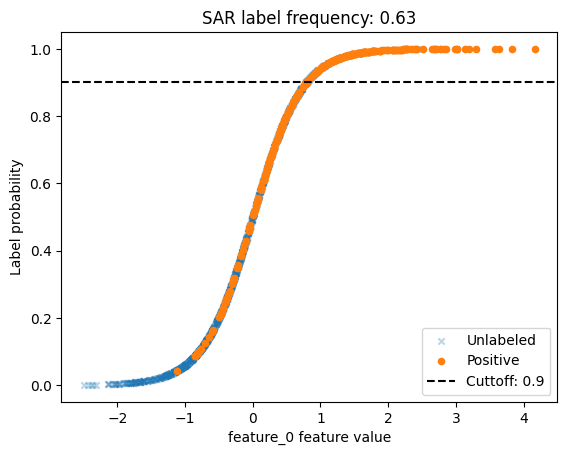

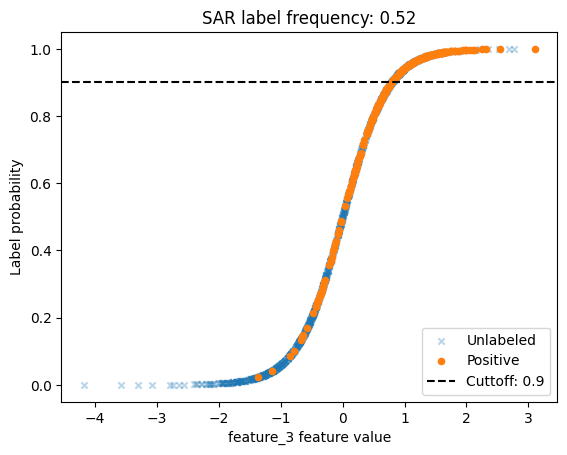

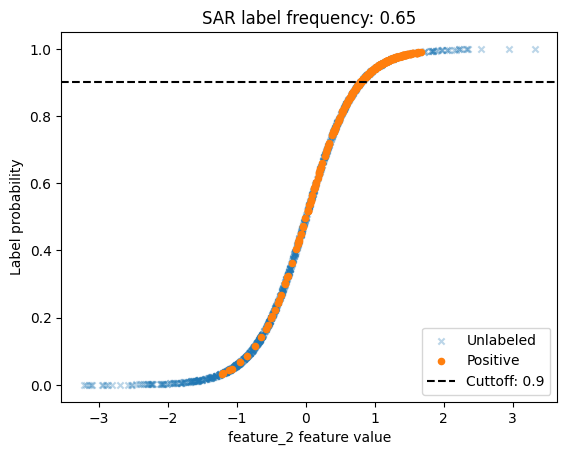

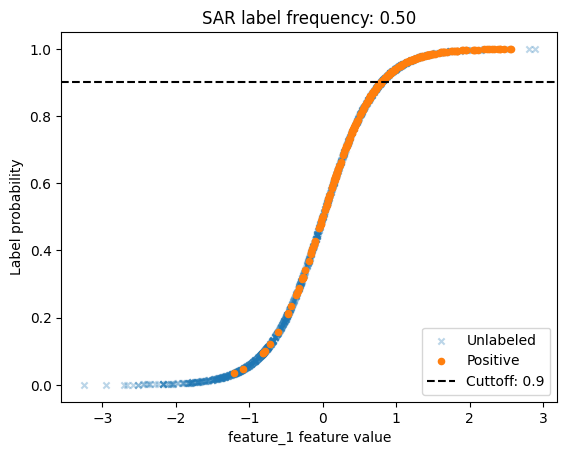

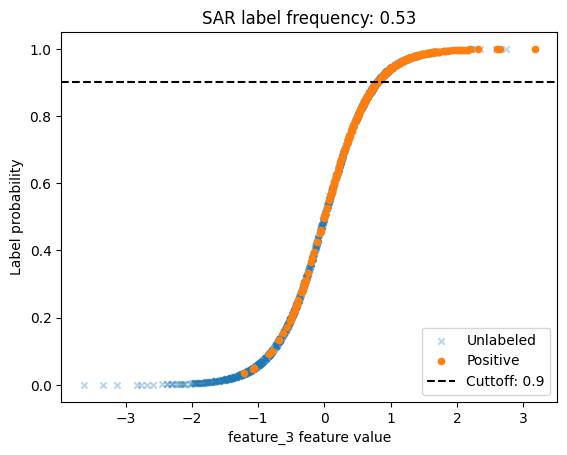

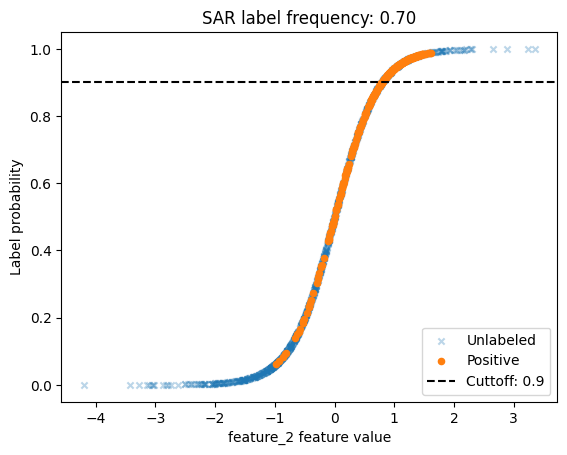

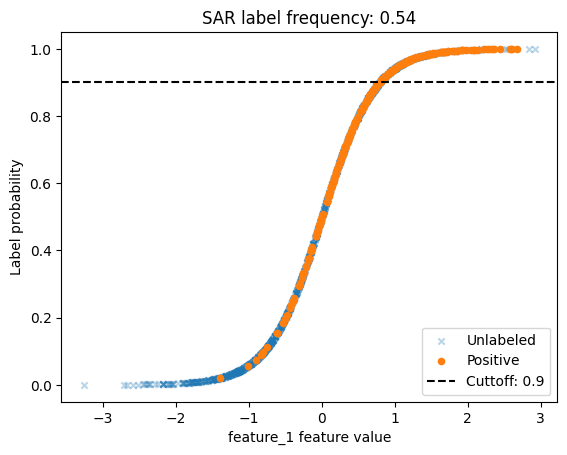

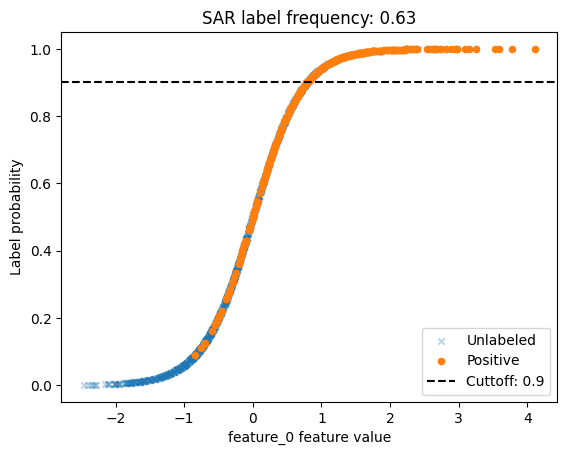

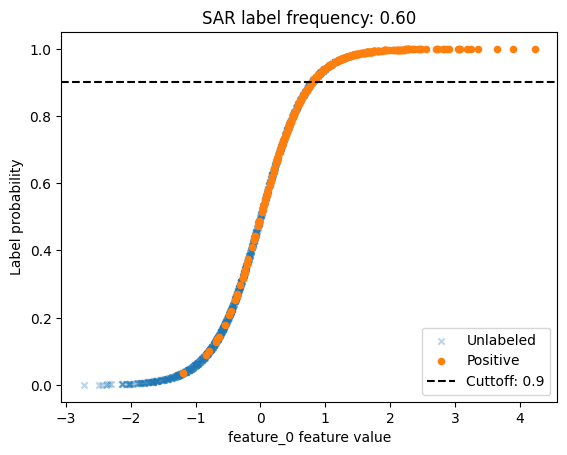

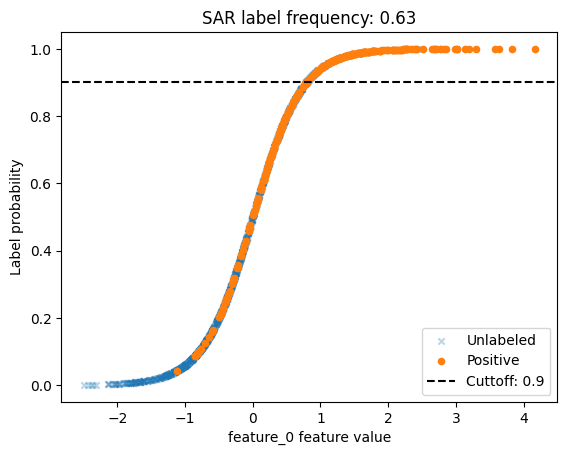

In [7]:
C = []
for iter in range(10):
    threshold = 0.9
    data = get_pd_dataset("mock")
    X_train,s_train,X_test,y_test = prepare_and_split_data(data,c=1,label_mechanism=f"sar_1_{threshold}",random_state=np.random.randint(0,10000)) 

    df = pd.DataFrame(X_train, columns=data.drop(columns=["target"]).columns)
    df["target"] = CONFIG.true_train_labels
    df["PU"] = s_train

    print(f"c={df['PU'].sum()/df['target'].sum():.2f}")
    plot_SAR(df, CONFIG.dominant_features, threshold=threshold)
    C.append(CONFIG.calculated_c)
    print(C[-1])


In [8]:
data

,feature_0,feature_1,feature_2,feature_3,target
0,-0.121390,2.881976,-4.341314,0.696213,0
1,-0.777887,-1.146795,-0.674256,-0.991424,0
2,-0.095450,-1.505709,-0.197189,-1.011886,0
3,-2.270317,0.586206,-2.334299,0.054815,0
4,0.191085,-0.656591,-1.326128,-2.693942,1
...,...,...,...,...,...
1623,-1.767548,-1.732928,-1.373919,-2.243184,0
1624,-1.433000,-0.161610,1.472122,1.358969,0
1625,-1.348602,1.999661,-3.745588,-0.064021,0
1626,-0.127173,0.307197,-2.442779,-0.550260,0


In [9]:
data = get_pd_dataset(name="mock")
X_train,s_train,X_test,y_test = prepare_and_split_data(data,c=1,label_mechanism="scar_1_0")

df = pd.DataFrame(X_train, columns=data.drop(columns=["target"]).columns)
df["PU"] = s_train
df["target"] = CONFIG.true_train_labels
df

,feature_0,feature_1,feature_2,feature_3,PU,target
0,0.747027,-0.453837,0.692852,1.345156,1,1
1,-1.667642,-0.611594,-1.597832,-1.685965,0,0
2,-0.670530,0.118838,1.079699,0.339273,1,1
3,-0.217022,0.231753,-0.504890,0.031210,0,0
4,0.018171,-0.400321,1.408907,0.558936,0,0
...,...,...,...,...,...,...
1297,-1.814432,0.936402,1.351368,1.624781,0,0
1298,-0.461964,-0.018033,0.536282,0.656727,0,0
1299,-0.618409,-0.328709,2.015685,1.140962,0,0
1300,-1.240057,-0.809647,-0.724027,-0.712822,0,0


In [10]:
clf = NaiveLogReg()
clf.fit(X_train, s_train)
clf_pred = clf.predict(X_test)
f1_score(y_test, clf_pred, average='macro')

Converged after 93 iterations


0.6657552973342447